In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('~/downloads/dataset.csv', index_col='Unnamed: 0')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\moshka/downloads/dataset.csv'

In [67]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [68]:
# базовая информация
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

In [69]:
# nan значени очень мало, следовательно данные записи можно удалить без потери важной статистики
df.isna().sum()
df.dropna(inplace=True)
df.isna().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [70]:
# избавляемся от дупликатов
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [71]:
# смотрим описательную статистику
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113549.000000,1.135490e+05,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,33.324433,2.280814e+05,0.567031,0.642091,5.309452,-8.243408,0.637866,0.084674,0.314064,0.155703,0.213613,0.474205,122.175745,3.904218
std,22.283855,1.064131e+05,0.173409,0.251053,3.560147,5.011422,0.480620,0.105762,0.331906,0.309217,0.190462,0.259204,29.972954,0.432117
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741840e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296000,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615880e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048700,0.273000,0.683000,140.074000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [72]:
# переводим миллисикунды в минуты для удобства и удаляем ненужны столбцы
df['duration_min'] = df['duration_ms'] / 60000
df.drop(columns=['track_id', 'duration_ms'], inplace=True)

In [73]:
# меняем False и True на 0 и 1
df['explicit'] = df['explicit'].replace({False : 0, True : 1})

<Axes: title={'center': 'Топ-10 популярных исполнителей'}, xlabel='Артисты', ylabel='Средняя популярность'>

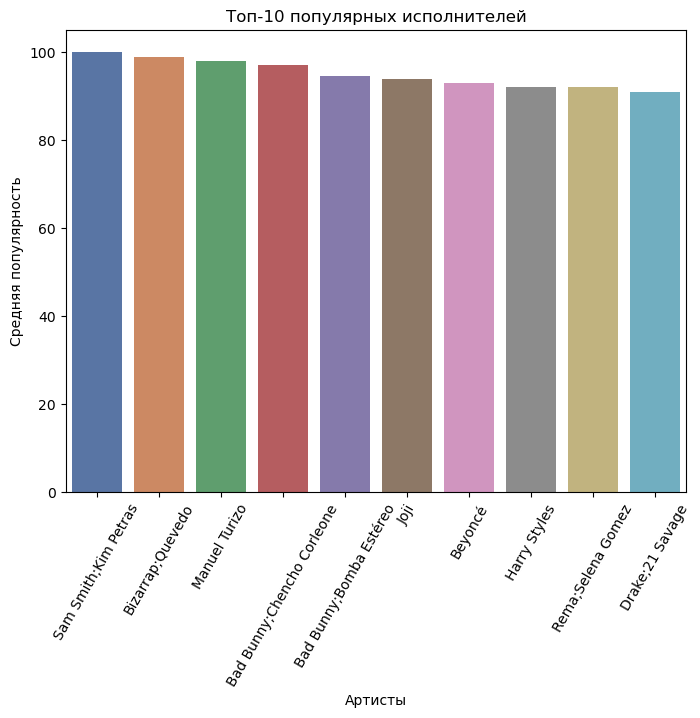

In [96]:
# анализ популярности исполнителей (топ 10)
artists_popularity = df.groupby('artists')['popularity'].mean().sort_values(ascending=False).to_frame().reset_index().head(10)
plt.figure(figsize=(8, 6))
plt.xlabel('Артисты')
plt.ylabel('Средняя популярность')
plt.title('Топ-10 популярных исполнителей')
plt.xticks(rotation=60)
sns.barplot(data=artists_popularity, x='artists', y='popularity', palette='deep')

<Axes: title={'center': 'Топ-10 популярных жанров'}, xlabel='Жанры', ylabel='Количество'>

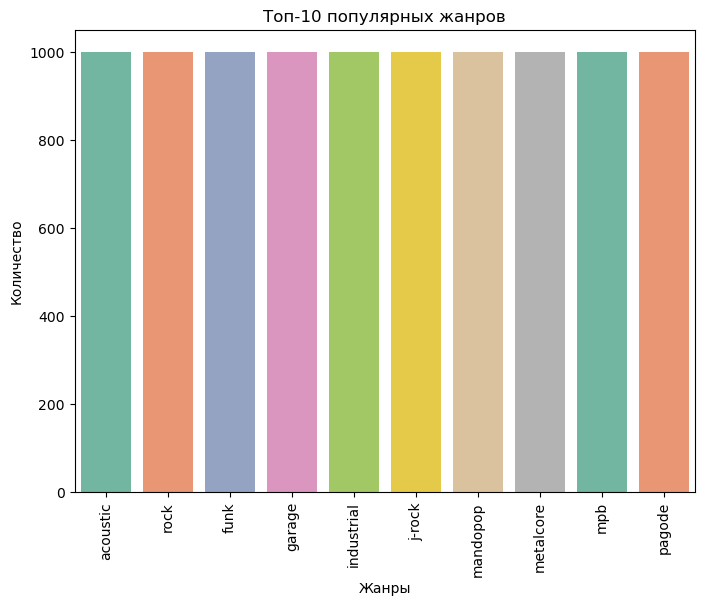

In [75]:
# исходные данные таковы, что всех жанров примерно поровну, так что сделать анализ по ним сложновато
genres_popularity = df.groupby('track_genre')['artists'].count().sort_values(ascending=False).to_frame().reset_index().head(10)
plt.figure(figsize=(8, 6))
plt.xticks(rotation=90)
plt.xlabel('Жанры')
plt.ylabel('Количество')
plt.title('Топ-10 популярных жанров')
sns.barplot(data=genres_popularity, x='track_genre', y='artists', palette='Set2')

<Axes: title={'center': 'Корреляция признаков'}>

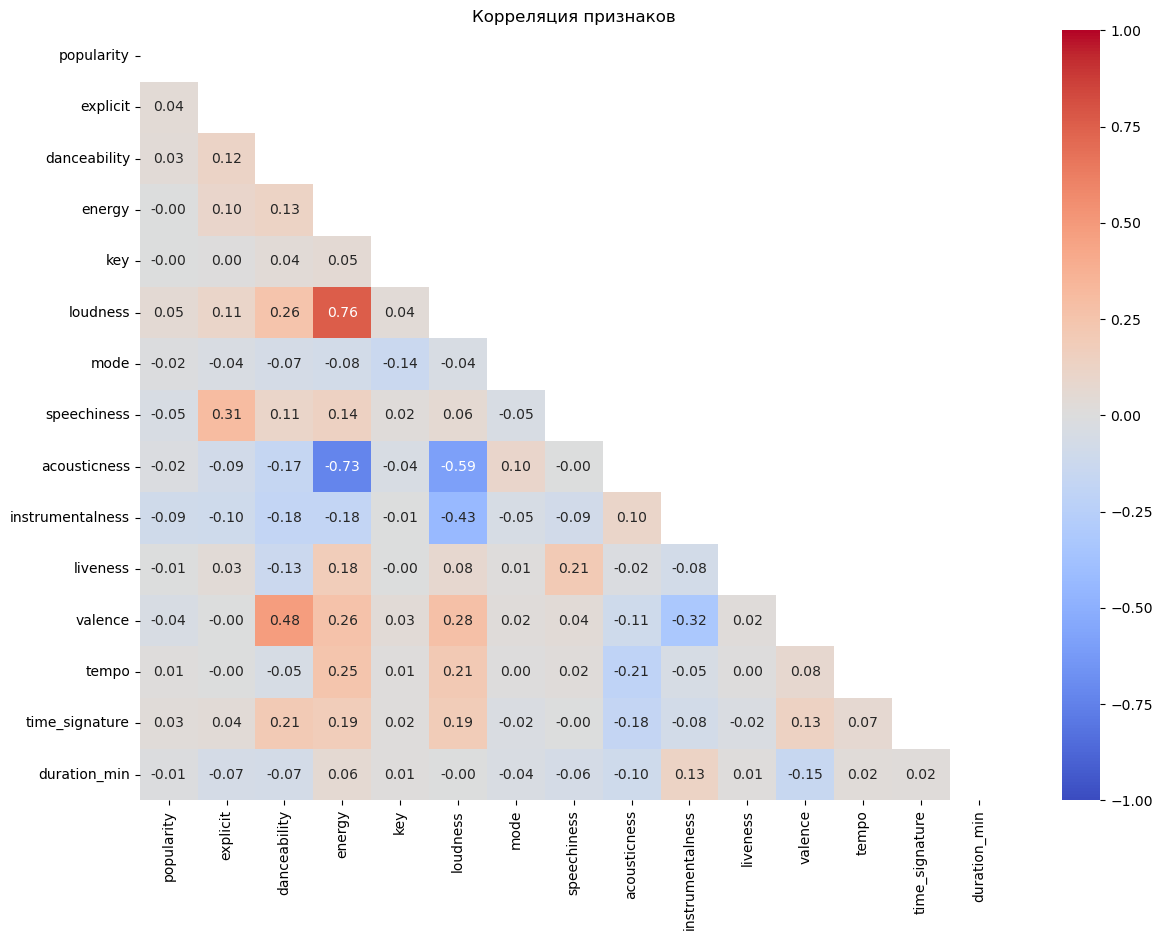

In [76]:
# на основе тепловой карты можно сделать несколько выводов:
# 1. Популярность не зависит от какого-то 1 признака, это совокупность всехвозможных факторов, в том числе и удачи
# 2. Часто энергичная музыка громкая и наоборот, громкая музыка часто энергичная (корреляция 0.8)
# 3. Обычно (корреляция 0.5) весёлая музыка больше танцевальна, и танцевальная музыка обычно весёлая
# 4. Акустическая музыка менее энергична и энергичная музыка менее акустична (корреляция -0.7)
# 5. Акустическая музыка не такая громкая, и громкая музыка менее акустична (корреляция -0.6)
# 6. Инструментальная музыка менее громкая, и громкая музыка менее инструментальная (корреляция -0.4)
correlation = df[['popularity', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'duration_min']].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
plt.figure(figsize=(14, 10))
plt.title('Корреляция признаков')
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

In [77]:
genres_big_duration = df.groupby('track_genre')['duration_min'].mean().sort_values(ascending=False).to_frame().head(10)
genres_small_duration = df.groupby('track_genre')['duration_min'].mean().sort_values().to_frame().head(10)

<Axes: title={'center': 'Топ-10 самых долгих жанров'}, xlabel='Жанры', ylabel='Продолжительность в минутах'>

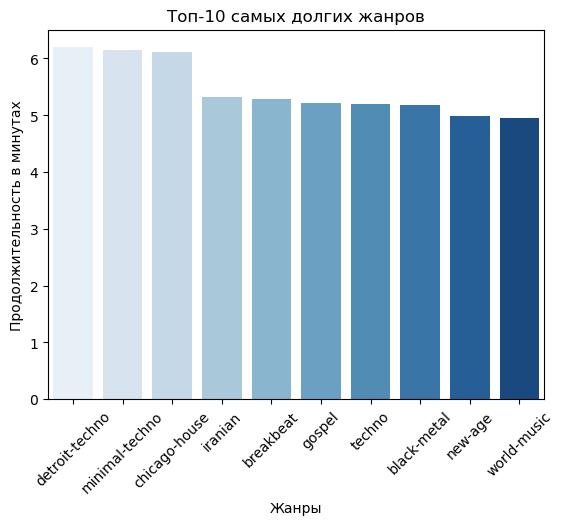

In [89]:
# топ-10 самых долгих по времени жанров
plt.xticks(rotation=45)
plt.xlabel('Жанры')
plt.ylabel('Продолжительность в минутах')
plt.title('Топ-10 самых долгих жанров')
sns.barplot(data=genres_big_duration, x='track_genre', y='duration_min', palette='Blues')

<Axes: title={'center': 'Топ-10 самых коротких жанров'}, xlabel='Жанры', ylabel='Продолжительность в минутах'>

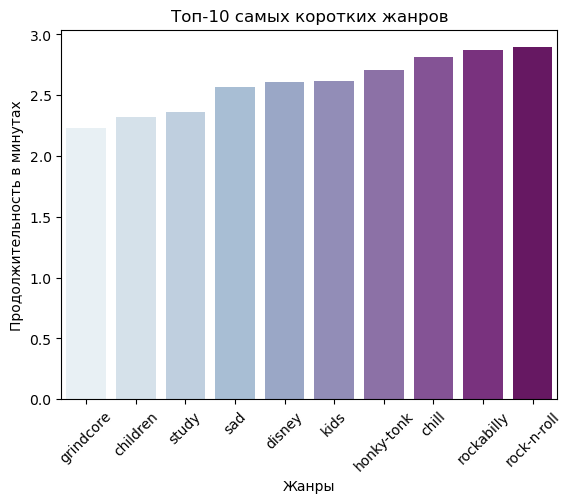

In [92]:
# топ 10 самых коротких жанров. Можно заметить, что часто встречаются детские жанры (kids, disney, children). Детям легче воспринимать короткую музыку
# чем более длинную
plt.xticks(rotation=45)
plt.xlabel('Жанры')
plt.ylabel('Продолжительность в минутах')
plt.title('Топ-10 самых коротких жанров')
sns.barplot(data=genres_small_duration, x='track_genre', y='duration_min', palette='BuPu')

<Axes: title={'center': 'Распределение оценок популярности'}, xlabel='Популярность', ylabel='Количество'>

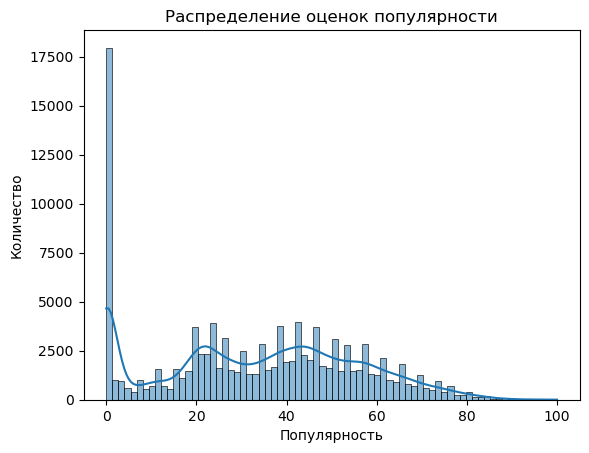

In [93]:
# данное распределение популярности нельзя назвать нормальным. Огромный скачок в области 0. Такое поведение
# может быть связано с большим количеством малоизвестных песен, загруженных на spotify пользователями, а остальные оценки популярности 
# распределены практически нормально (исключая бимодальность в области 20 и 40).
plt.xlabel('Популярность')
plt.ylabel('Количество')
plt.title('Распределение оценок популярности')
sns.histplot(data=df, x='popularity', kde=True)

Text(0, 0.5, 'Количество треков')

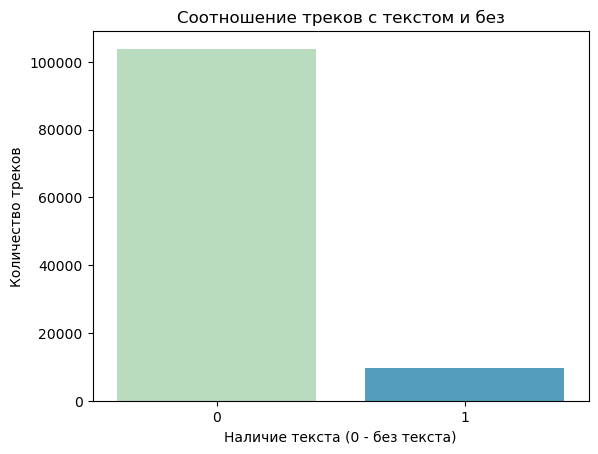

In [94]:
# Можем увидить большое преимущество отсутствие текста у песен.
sns.countplot(data=df, x='explicit', palette='GnBu')
plt.title('Соотношение треков с текстом и без')
plt.xlabel('Наличие текста (0 - без текста)')
plt.ylabel('Количество треков')

In [82]:
popularity_by_genre = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).reset_index().head(10)

<Axes: title={'center': 'Топ-10 популярных жанров'}, xlabel='Жанры', ylabel='Средняя популярность'>

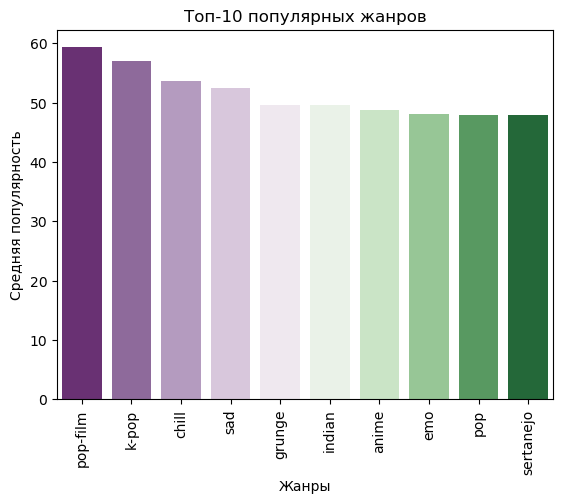

In [95]:
plt.xticks(rotation=90)
plt.xlabel('Жанры')
plt.ylabel('Средняя популярность')
plt.title('Топ-10 популярных жанров')
sns.barplot(data=popularity_by_genre, x='track_genre', y='popularity', palette='PRGn')

In [84]:
df.to_csv('songs_dataset.csv')